# Constructing Brownian Motion

## Mathematical Goal

Construct Brownian motion from its defining properties and verify that the simulated paths exhibit the qualitative behavior predicted by theory.

## Questions

1. How does changing the timestep affect the appearance of the path?
2. How much variability is there between different realizations?
3. Do the paths visually appear nowhere differentiable?
4. Does Brownian motion exhibit self-similarity?

In [25]:
# Constructed Brownian motion!
import sys
from pathlib import Path

# Add the project root to Python's search path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from stochastic.brownian import generate

import matplotlib.pyplot as plt

Text(0, 0.5, 'B(t)')

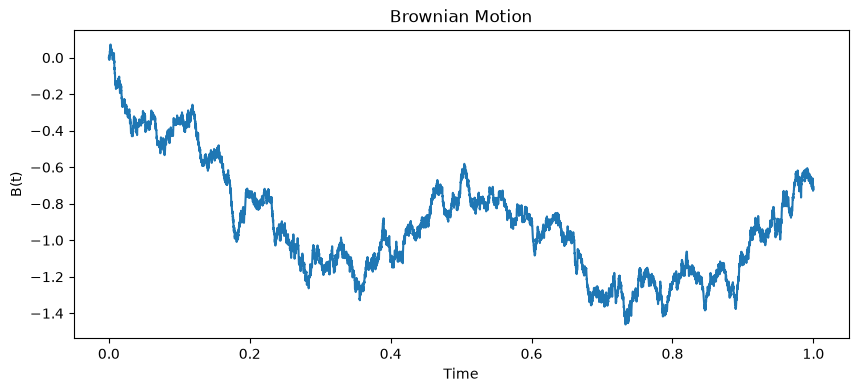

In [24]:
t, B = generate(n=10000)
plt.figure(figsize=(10,4))

plt.plot(t,B)

plt.title("Brownian Motion")

plt.xlabel("Time")

plt.ylabel("B(t)")

Text(0, 0.5, 'B(t)')

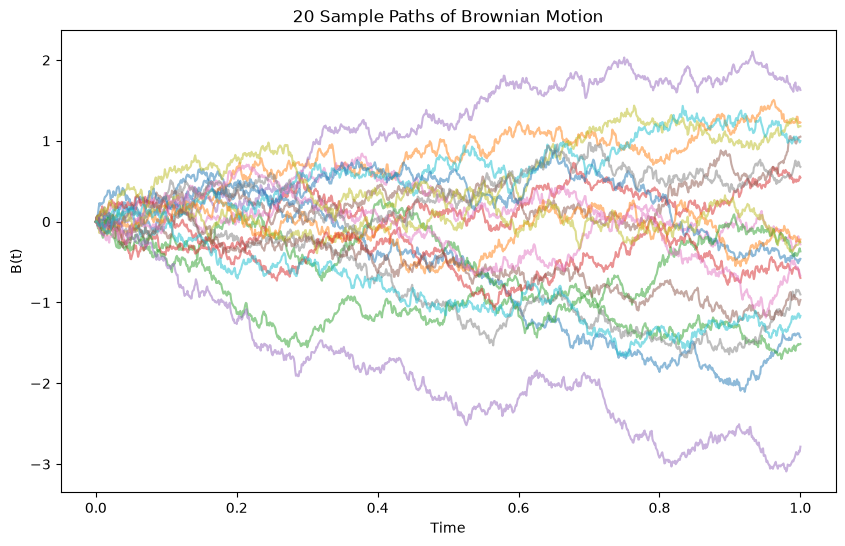

In [4]:
plt.figure(figsize=(10,6))

for i in range(20):
    t, B = generate(seed=i)
    plt.plot(t, B, alpha=0.5)

plt.title("20 Sample Paths of Brownian Motion")
plt.xlabel("Time")
plt.ylabel("B(t)")

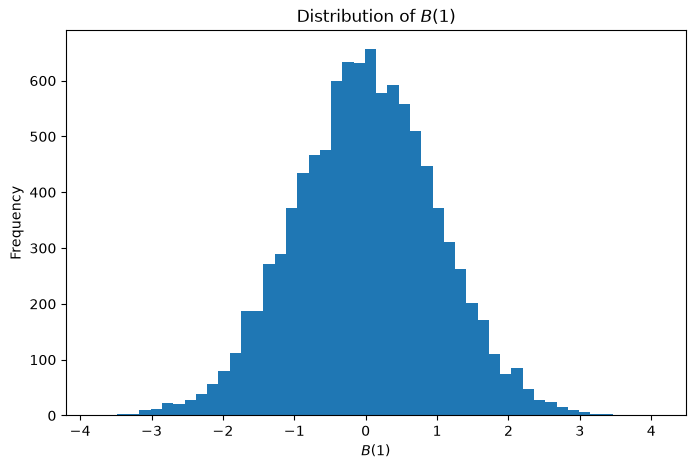

In [12]:
endpoints = []

for _ in range(10000):
    _, B = generate()
    endpoints.append(B[-1])
plt.figure(figsize=(8,5))

plt.hist(endpoints, bins=50)

plt.title(r"Distribution of $B(1)$")

plt.xlabel(r"$B(1)$")

plt.ylabel("Frequency")

plt.show()

# Quadratic Variation

## Questions
1. Does it actually converge to T
2. If we could in theory find another integrable stochastic process, it would have to satisfy some form of $$dB^2 = dt$$

In [30]:
from stochastic.brownian import generate
from analysis.variation import quadratic_variation
from analysis.variation import linear_variation


ns = [10, 20, 50, 100, 200, 500, 1000, 5000]

Q = []

for n in ns:
    _, B = generate(T=1, n=n)
    Q.append(quadratic_variation(B))

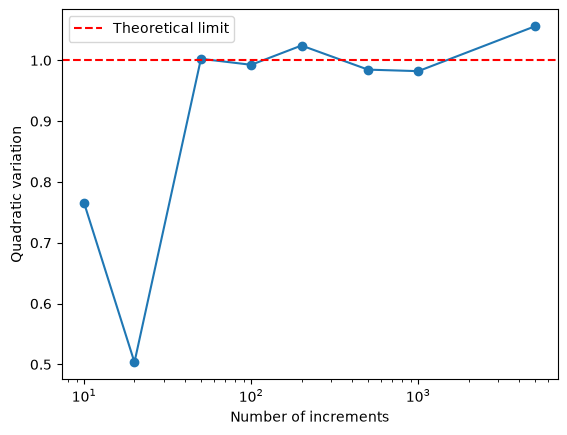

In [31]:
plt.plot(ns, Q, 'o-')
plt.axhline(1, color='red', linestyle='--', label='Theoretical limit')
plt.xscale('log')
plt.xlabel("Number of increments")
plt.ylabel("Quadratic variation")
plt.legend()
plt.show()

Note: for higher orders attempts, the integrals acrew different terms, making it less simple than brownian motion